In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from hmmlearn import hmm
from scipy import stats

## LOAD DATA

In [ ]:
prices = pd.read_csv('pharma_prices.csv', index_col=0, parse_dates=True)
returns = pd.read_csv('pharma_returns.csv', index_col=0, parse_dates=True)
strong_pairs_df = pd.read_csv('strong_pairs.csv')

print(f"Loaded prices shape: {prices.shape}")
print(f"Loaded returns shape: {returns.shape}")
print(f"Loaded {len(strong_pairs_df)} strong pairs")

Loaded prices shape: (1467, 39)
Loaded returns shape: (1466, 39)
Loaded 36 strong pairs


## COMPUTE MARKET-WIDE REGIME FEATURES

In [ ]:
# Compute market-level metrics
market_returns = returns.mean(axis=1)  # Average return across all pharma stocks
market_volatility = returns.rolling(window=30).std().mean(axis=1)  # Rolling 30-day volatility
market_correlation = returns.rolling(window=60).corr().groupby(level=0).apply(
    lambda x: x.values[np.triu_indices_from(x.values, k=1)].mean() if x.shape[0] > 1 else np.nan
)

# Combine into feature matrix for HMM
hmm_features = pd.DataFrame({
    'Market_Return': market_returns,
    'Market_Volatility': market_volatility,
    'Avg_Correlation': market_correlation
}).dropna()

# Standardize features (important for HMM)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
hmm_features_scaled = scaler.fit_transform(hmm_features)

print(f"\nHMM Features shape: {hmm_features_scaled.shape}")
print(f"\nFeature Statistics (after standardization):")
print(pd.DataFrame(hmm_features_scaled, columns=hmm_features.columns).describe().round(3))


HMM Features shape: (1407, 3)

Feature Statistics (after standardization):
       Market_Return  Market_Volatility  Avg_Correlation
count       1407.000           1407.000         1407.000
mean           0.000              0.000            0.000
std            1.000              1.000            1.000
min           -3.524             -1.845           -1.811
25%           -0.608             -0.721           -0.734
50%           -0.001             -0.048           -0.231
75%            0.593              0.618            0.726
max            4.511              4.307            2.740


## TRAIN HIDDEN MARKOV MODEL

In [ ]:
# Train HMM with 3 hidden states (Calm, Normal, Volatile)
n_states = 3
model = hmm.GaussianHMM(n_components=n_states, covariance_type="full", n_iter=10000, random_state=42)

print(f"\nTraining HMM with {n_states} hidden states...")
model.fit(hmm_features_scaled)

# Predict hidden states
hidden_states = model.predict(hmm_features_scaled)

# Predict probabilities
state_probs = model.predict_proba(hmm_features_scaled)

print(f"HMM Training Complete!")
print(f"\nTransition Matrix:\n{model.transmat_.round(3)}")
print(f"\nMeans of each state:\n{model.means_.round(3)}")

# Add states to dataframe
hmm_features['State'] = hidden_states
hmm_features['State_Name'] = hmm_features['State'].map({
    0: 'State_0',
    1: 'State_1',
    2: 'State_2'
})

print(f"\nRegime Distribution:")
print(hmm_features['State_Name'].value_counts().sort_index())


Training HMM with 3 hidden states...
HMM Training Complete!

Transition Matrix:
[[0.002 0.998 0.   ]
 [0.936 0.052 0.013]
 [0.    0.002 0.998]]

Means of each state:
[[-0.049  0.814  1.234]
 [ 0.166  0.817  1.226]
 [-0.03  -0.397 -0.599]]

Regime Distribution:
State_Name
State_0    229
State_1    232
State_2    946
Name: count, dtype: int64


## REGIME INTERPRETATION & CHARACTERIZATION

In [ ]:
# Characterize each state by its average volatility
state_stats = pd.DataFrame()

for state in range(n_states):
    mask = hmm_features['State'] == state
    state_stats.loc[state, 'Mean_Return'] = hmm_features.loc[mask, 'Market_Return'].mean()
    state_stats.loc[state, 'Mean_Volatility'] = hmm_features.loc[mask, 'Market_Volatility'].mean()
    state_stats.loc[state, 'Mean_Correlation'] = hmm_features.loc[mask, 'Avg_Correlation'].mean()
    state_stats.loc[state, 'Count_Days'] = mask.sum()
    state_stats.loc[state, 'Pct_Days'] = mask.sum() / len(hmm_features) * 100

print("\nState Characterization:")
print(state_stats.round(3))

# Label states by volatility (ascending)
vol_ranking = state_stats['Mean_Volatility'].argsort()
state_labels = {
    vol_ranking[0]: 'Calm',
    vol_ranking[1]: 'Normal',
    vol_ranking[2]: 'Volatile'
}

hmm_features['Regime'] = hmm_features['State'].map(state_labels)
print(f"\nRegime Mapping: {state_labels}")


State Characterization:
   Mean_Return  Mean_Volatility  Mean_Correlation  Count_Days  Pct_Days
0        0.000            0.029             0.412       229.0    16.276
1        0.002            0.029             0.411       232.0    16.489
2        0.000            0.023             0.252       946.0    67.235

Regime Mapping: {np.int64(2): 'Calm', np.int64(0): 'Normal', np.int64(1): 'Volatile'}


## VISUALIZATION

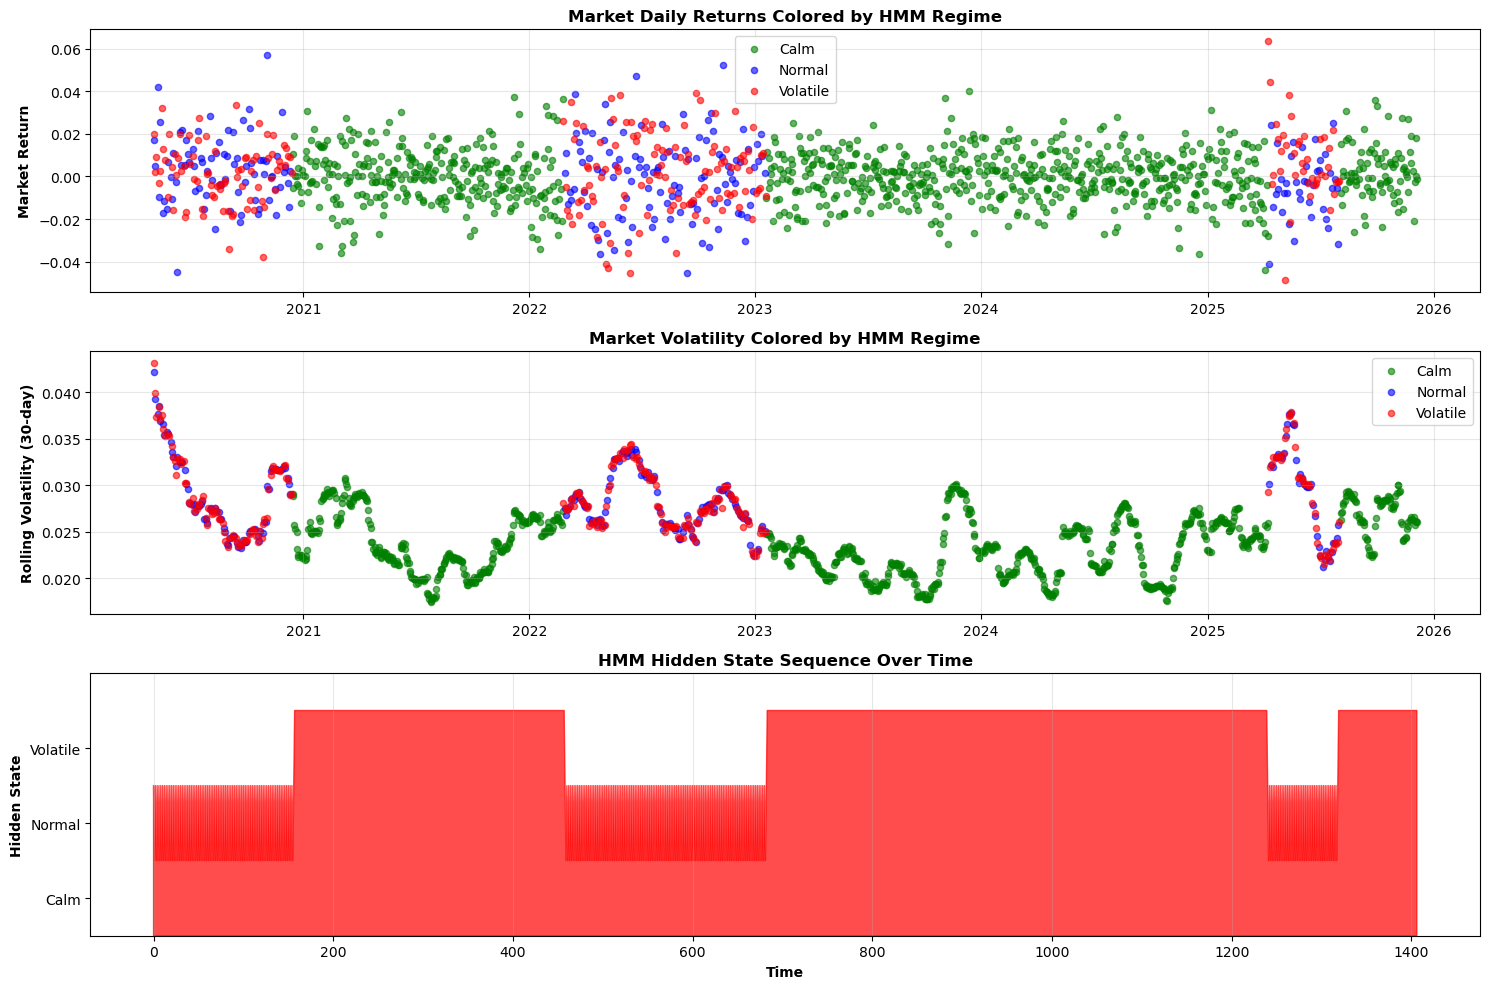

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Plot 1: Market Return with Regime Colors
ax1 = axes[0]
colors = {'Calm': 'green', 'Normal': 'blue', 'Volatile': 'red'}
for regime in ['Calm', 'Normal', 'Volatile']:
    mask = hmm_features['Regime'] == regime
    ax1.scatter(hmm_features.index[mask], hmm_features.loc[mask, 'Market_Return'],
               label=regime, alpha=0.6, s=20, color=colors[regime])
ax1.set_ylabel('Market Return', fontweight='bold')
ax1.set_title('Market Daily Returns Colored by HMM Regime', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Market Volatility with Regime Colors
ax2 = axes[1]
for regime in ['Calm', 'Normal', 'Volatile']:
    mask = hmm_features['Regime'] == regime
    ax2.scatter(hmm_features.index[mask], hmm_features.loc[mask, 'Market_Volatility'],
               label=regime, alpha=0.6, s=20, color=colors[regime])
ax2.set_ylabel('Rolling Volatility (30-day)', fontweight='bold')
ax2.set_title('Market Volatility Colored by HMM Regime', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: State Sequence Over Time
ax3 = axes[2]
state_colors = np.array([colors.get(regime, 'gray') for regime in hmm_features['Regime']])
ax3.fill_between(range(len(hmm_features)), 0, hmm_features['State'] + 1, color=state_colors, alpha=0.7)
ax3.set_ylabel('Hidden State', fontweight='bold')
ax3.set_xlabel('Time', fontweight='bold')
ax3.set_title('HMM Hidden State Sequence Over Time', fontsize=12, fontweight='bold')
ax3.set_ylim([0, 3.5])
ax3.set_yticks([0.5, 1.5, 2.5])
ax3.set_yticklabels(['Calm', 'Normal', 'Volatile'])
ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## STATE PROBABILITY HEATMAP

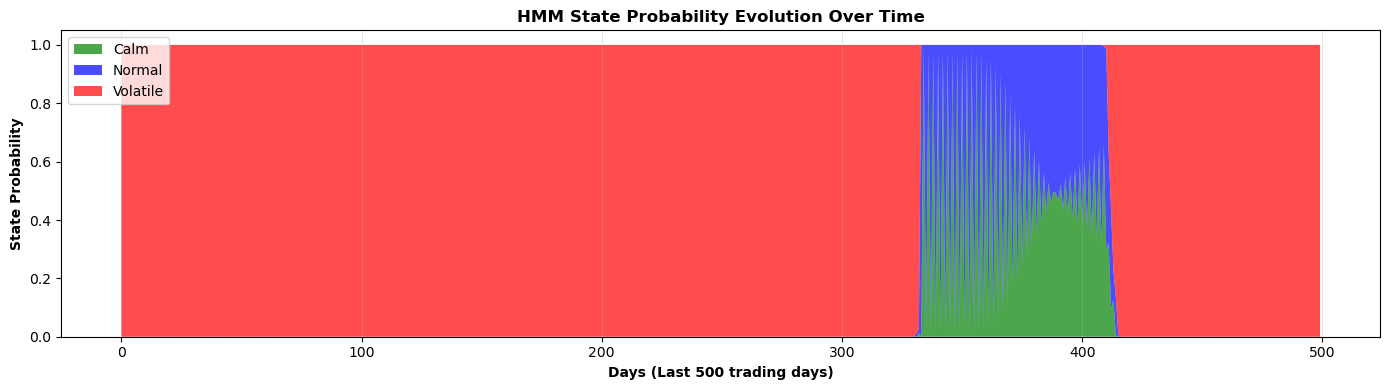

In [ ]:
# Plot state probabilities over time (last 500 days for clarity)
fig, ax = plt.subplots(figsize=(14, 4))

recent_idx = -500
recent_probs = state_probs[recent_idx:]
recent_dates = hmm_features.index[recent_idx:]

# Stack plot
ax.stackplot(range(len(recent_probs)),
            recent_probs[:, 0],
            recent_probs[:, 1],
            recent_probs[:, 2],
            labels=['Calm', 'Normal', 'Volatile'],
            colors=['green', 'blue', 'red'],
            alpha=0.7)

ax.set_xlabel('Days (Last 500 trading days)', fontweight='bold')
ax.set_ylabel('State Probability', fontweight='bold')
ax.set_title('HMM State Probability Evolution Over Time', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## SAVE HMM DATA

In [ ]:
# Save regime data
hmm_features.to_csv('hmm_regimes.csv')

# Save model parameters
np.save('hmm_model_means.npy', model.means_)
np.save('hmm_model_covariance.npy', model.covars_)
np.save('hmm_model_transmat.npy', model.transmat_)
np.save('hmm_model_startprob.npy', model.startprob_)

# Save scaler for use in trading
import pickle
with open('hmm_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✓ Saved: hmm_regimes.csv")
print("✓ Saved: HMM model parameters (*.npy)")
print("✓ Saved: hmm_scaler.pkl")

✓ Saved: hmm_regimes.csv
✓ Saved: HMM model parameters (*.npy)
✓ Saved: hmm_scaler.pkl
